In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../000_naive_baseline_models/naive_baseline_results.csv", index_col=["Datetime"], parse_dates=["Datetime"])

In [3]:
df.head()

,load
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


# Prepearing data for Deep Learning Models

# generating features for algorithm understanding    

In [4]:
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month
df['year'] = df.index.year
df.head()

,load,hour,dayofweek,month,year
Datetime,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,2002
2002-01-01 02:00:00,29265.0,2,1,1,2002
2002-01-01 03:00:00,28357.0,3,1,1,2002
2002-01-01 04:00:00,27899.0,4,1,1,2002
2002-01-01 05:00:00,28057.0,5,1,1,2002


In [5]:
df.tail()

,load,hour,dayofweek,month,year
Datetime,,,,,
2018-08-02 20:00:00,44057.0,20,3,8,2018
2018-08-02 21:00:00,43256.0,21,3,8,2018
2018-08-02 22:00:00,41552.0,22,3,8,2018
2018-08-02 23:00:00,38500.0,23,3,8,2018
2018-08-03 00:00:00,35486.0,0,4,8,2018


In [6]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled= scaler.fit_transform(df[['load','hour','dayofweek','month','year']])
scaled.shape
scaled[:5]  # Display the first 5 rows of the scaled data

array([[0.3339092 , 0.04347826, 0.16666667, 0.        , 0.        ],
       [0.31014432, 0.08695652, 0.16666667, 0.        , 0.        ],
       [0.29101443, 0.13043478, 0.16666667, 0.        , 0.        ],
       [0.28136522, 0.17391304, 0.16666667, 0.        , 0.        ],
       [0.28469399, 0.2173913 , 0.16666667, 0.        , 0.        ]])

> If we want to predict the next 24 hours of energy demand , we might use the last 168 hours (one week) as input. So each trianign sample looks like this:

> Input: [Hour t - 168...t-1]
> Output: [Hour t...t+23]

In [7]:
def make_windowed_dataset(series, window_size,horizon=24):              
    X = []
    y = []
    for i in range(len(series) - window_size-horizon):
        X.append(series[i:i + window_size])
        y.append(series[i + window_size:i + window_size + horizon]) # Predicting only the load value 24 hours ahead    
    return np.array(X), np.array(y)
X,y= make_windowed_dataset(scaled[:,0,], window_size=168, horizon=24) # 168 hours = 7 days and we only need the load column for training 
X.shape, y.shape

((145170, 168), (145170, 24))

# Train and Test data Preparation 
#### Give the last week of energy load (X). What will be the future energy load for tommrow (Y)

In [8]:
# splitting the data into training and testing sets
split_time = int(len(X) * 0.8) # 80% for training, 20% for testing
X_train, X_test = X[:split_time], X[split_time:]
y_train, y_test = y[:split_time], y[split_time:]
print("training data length:", len(X_train))    
print("testing data length:", len(X_test))
print("training data y:", len(y_train))    
print("testing data y length:", len(y_test))
print("check shapes:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

training data length: 116136
testing data length: 29034
training data y: 116136
testing data y length: 29034
check shapes: (116136, 168) (116136, 24) (29034, 168) (29034, 24)


# Training the train and test data with Neural Networks

In [9]:
INPUT_SHAPE = X_train.shape[1:]  # (window_size, num_features)
OUTPUT_SIZE = y_train.shape[1]    # horizon size  this 24 hour peroid of forecast   

##### Dense model for base linbe and simplicity understanding what is going on ? If our data can even fit a deep learning model enough to detect some patters ? 


In [10]:
####pip install tensorflow==2.15.0

In [11]:
import tensorflow as tf
from tensorflow import keras
import tensorflow as tf
print("TF imported:", tf.__version__)
print("Keras imported")
layers = keras.layers   
model = keras.Sequential([
    layers.InputLayer(INPUT_SHAPE),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(OUTPUT_SIZE)  # Output layer for 24-hour forecast
])
# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
# Display the model summary         
model.summary()

2026-01-10 09:23:09.312238: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-10 09:23:09.334890: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF imported: 2.15.0
Keras imported
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               21632     
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 24)                1560      
                                                                 
Total params: 31448 (122.84 KB)
Trainable params: 31448 (122.84 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [12]:
# brief representation
print(model)

reshape

In [13]:
train_data_y_dense = y_train.reshape(y_train.shape[0], y_train.shape[-1])
test_data_y_dense = y_test.reshape(y_test.shape[0], y_test.shape[-1])    

print("X train shape",X_train.shape)
print("Y train dense shape",train_data_y_dense.shape)


X train shape (116136, 168)
Y train dense shape (116136, 24)


In [14]:
import os
import random

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

history = model.fit(
    X_train, 
    train_data_y_dense,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
     shuffle=True  # you can keep this true, but seed helps with reproducibility
)

Epoch 1/20
2904/2904 [==============================] - 4s 1ms/step - loss: 0.0033 - mae: 0.0411 - val_loss: 0.0028 - val_mae: 0.0392
Epoch 2/20
2904/2904 [==============================] - 3s 1ms/step - loss: 0.0021 - mae: 0.0345 - val_loss: 0.0020 - val_mae: 0.0329
Epoch 3/20
2904/2904 [==============================] - 3s 1ms/step - loss: 0.0020 - mae: 0.0328 - val_loss: 0.0020 - val_mae: 0.0321
Epoch 4/20
2904/2904 [==============================] - 3s 1ms/step - loss: 0.0018 - mae: 0.0315 - val_loss: 0.0018 - val_mae: 0.0305
Epoch 5/20
2904/2904 [==============================] - 4s 1ms/step - loss: 0.0018 - mae: 0.0307 - val_loss: 0.0020 - val_mae: 0.0325
Epoch 6/20
2904/2904 [==============================] - 5s 2ms/step - loss: 0.0017 - mae: 0.0302 - val_loss: 0.0025 - val_mae: 0.0376
Epoch 7/20
2904/2904 [==============================] - 4s 1ms/step - loss: 0.0017 - mae: 0.0299 - val_loss: 0.0019 - val_mae: 0.0318
Epoch 8/20
2904/2904 [==============================] - 4s 1ms

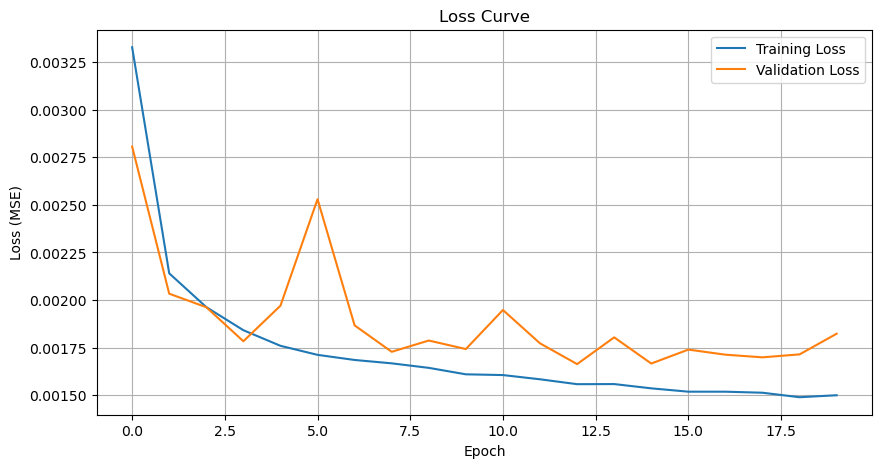

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)

plt.show()


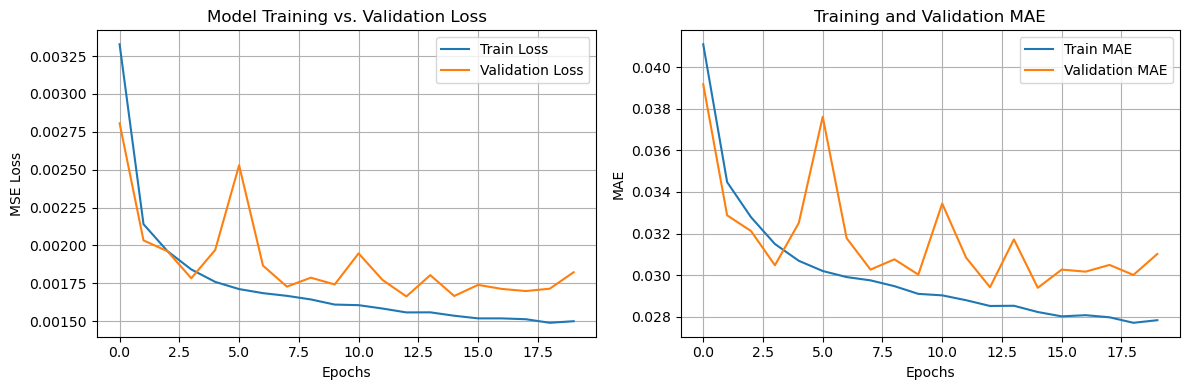

In [16]:
fix,axes = plt.subplots(1, 2, figsize=(12, 4)) 
# Plot training & validation loss values
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Training vs. Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True)


# Plot MAE values
if 'mae' in history.history:
    axes[1].plot(history.history['mae'], label='Train MAE')
    axes[1].plot(history.history['val_mae'], label='Validation MAE')
    axes[1].set_title('Training and Validation MAE')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(True)
else:
    axes[1].text(0.5, 0.5, 'MAE not available', horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes)
    axes[1].set_title('Training and Validation MAE')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('MAE')
plt.tight_layout()
plt.show()  

## Prediction with Dense Model

In [17]:
predict_dense_model = model.predict(X_test)

908/908 [==============================] - 1s 659us/step


In [30]:
#let save the predictions to a csv file for later process to comapre with LSTM model
df_dense_pred = pd.DataFrame(
    predict_dense_model,
    columns=[f"hour_{i}" for i in range(24)]
)

df_dense_pred.to_csv("dense_model_predictions.csv", index=False)

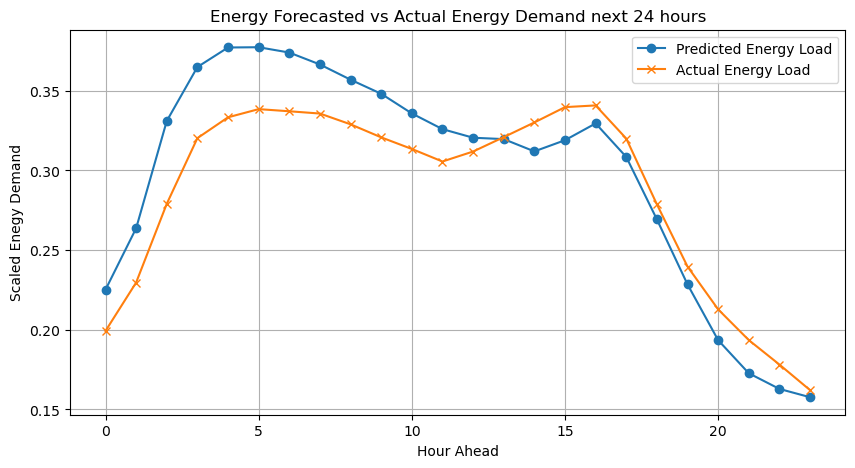

In [18]:
sample_index = 1  # we can chnage this to visualize different samples
actual_load =test_data_y_dense[sample_index]
predicted_load = predict_dense_model[sample_index]
plt.figure(figsize=(10, 5))
plt.plot(actual_load, label='Predicted Energy Load', marker='o')
plt.plot(predicted_load, label='Actual Energy Load', marker='x') 
plt.title("Energy Forecasted vs Actual Energy Demand next 24 hours")
plt.xlabel("Hour Ahead")
plt.ylabel("Scaled Enegy Demand") # use the scaled form here
plt.legend()
plt.grid(True)
plt.show()      

# Dense MAE

In [19]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error
mae = mean_absolute_error(y_test.flatten(),predict_dense_model.flatten())
rmse = root_mean_squared_error(y_test.flatten(), predict_dense_model.flatten())       
mape = mean_absolute_percentage_error(y_test.flatten(), predict_dense_model.flatten())                     
print("Dense Model Performance on Test Set:")
print("MAE: {:.2f} MW".format(mae))
print("RMSE: {:.2f} MW".format(rmse))
print("MAPE: {:.2f}%".format(mape * 100))

Dense Model Performance on Test Set:
MAE: 0.03 MW
RMSE: 0.04 MW
MAPE: 9.24%


In [25]:
df.to_csv("feature_engineered_load.csv")
#scaled.to_csv("scaled_load.csv")